In [ ]:
from google.colab import files
import zipfile
import os

# Upload the zip file
uploaded = files.upload()

Saving archive (8).zip to archive (8).zip


In [ ]:

# Unzip the file
with zipfile.ZipFile('archive (8).zip', 'r') as zip_ref:
    zip_ref.extractall('archive (8)')


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from sklearn.metrics import classification_report, confusion_matrix

# Step 1: Define paths based on your structure
base_dir = '/content/archive (8)/The IQ-OTHNCCD lung cancer dataset/The IQ-OTHNCCD lung cancer dataset'
benign_dir = os.path.join(base_dir, 'Bengin cases')  # Note: Typo in "Bengin" matches your folder name
malignant_dir = os.path.join(base_dir, 'Malignant cases')
normal_dir = os.path.join(base_dir, 'Normal cases')


In [ ]:
# Step 2: Create DataFrame with image paths and labels
image_paths = []
labels = []

In [ ]:
# Process Benign cases
for img_file in os.listdir(benign_dir):
    if img_file.endswith('.JPG') or img_file.endswith('.jpg'):
        image_paths.append(os.path.join(benign_dir, img_file))
        labels.append('Benign')

# Process Malignant cases
for img_file in os.listdir(malignant_dir):
    if img_file.endswith('.JPG') or img_file.endswith('.jpg'):
        image_paths.append(os.path.join(malignant_dir, img_file))
        labels.append('Malignant')

# Process Normal cases
for img_file in os.listdir(normal_dir):
    if img_file.endswith('.JPG') or img_file.endswith('.jpg'):
        image_paths.append(os.path.join(normal_dir, img_file))
        labels.append('Normal')


Class distribution:
label
Malignant    561
Normal       416
Benign       120
Name: count, dtype: int64


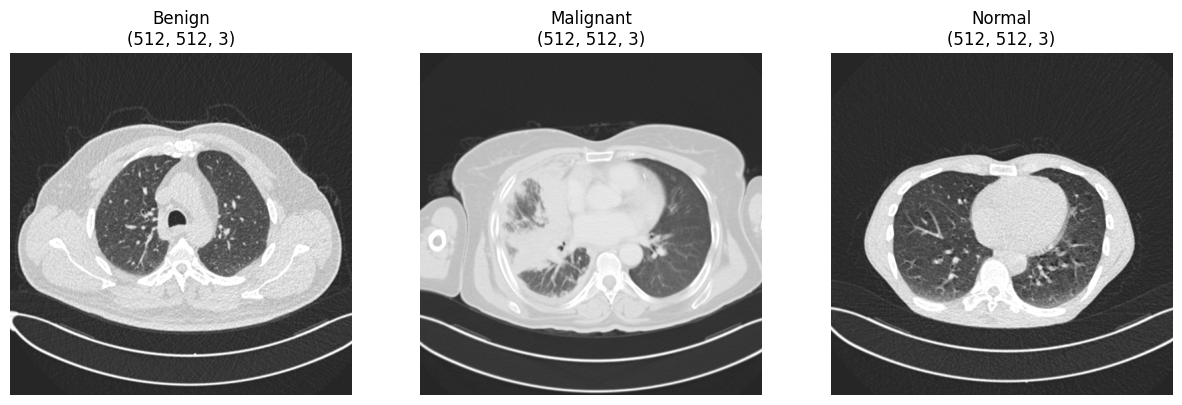

In [ ]:
# Create DataFrame
df = pd.DataFrame({'image_path': image_paths, 'label': labels})

# Check class distribution
print("Class distribution:")
print(df['label'].value_counts())

# Step 3: Visualize sample images
plt.figure(figsize=(15, 5))
for i, (label, sample_df) in enumerate(df.groupby('label')):
    img_path = sample_df.iloc[0]['image_path']
    img = plt.imread(img_path)
    plt.subplot(1, 3, i+1)
    plt.imshow(img, cmap='gray')
    plt.title(f"{label}\n{img.shape}")
    plt.axis('off')
plt.show()

In [ ]:
# Create DataFrame
df = pd.DataFrame({'image_path': image_paths, 'label': labels})

# Split dataset into train, validation, and test sets
train_df, test_df = train_test_split(df, test_size=0.15, stratify=df['label'], random_state=42)
train_df, val_df = train_test_split(train_df, test_size=0.10, stratify=train_df['label'], random_state=42)

# Optional: Print counts
print("✅ Data splits:")
print(f"Training: {len(train_df)} images")
print(f"Validation: {len(val_df)} images")
print(f"Testing: {len(test_df)} images")

✅ Data splits:
Training: 838 images
Validation: 94 images
Testing: 165 images


In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Step 5: Improved Data Generators
img_size = (224, 224)
batch_size = 32

# Enhanced training augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.15,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

# Shuffle only training
train_generator = train_datagen.flow_from_dataframe(
    train_df,
    x_col='image_path',
    y_col='label',
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=True
)

val_generator = val_datagen.flow_from_dataframe(
    val_df,
    x_col='image_path',
    y_col='label',
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

test_generator = test_datagen.flow_from_dataframe(
    test_df,
    x_col='image_path',
    y_col='label',
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

# Class weights (optional, useful for imbalance)
labels_unique = df['label'].unique()
class_weights = compute_class_weight(class_weight='balanced', classes=labels_unique, y=df['label'])
class_weights = dict(zip(train_generator.class_indices.values(), class_weights))
print("Class weights:", class_weights)


Found 838 validated image filenames belonging to 3 classes.
Found 94 validated image filenames belonging to 3 classes.
Found 165 validated image filenames belonging to 3 classes.
Class weights: {0: np.float64(3.047222222222222), 1: np.float64(0.6518122400475341), 2: np.float64(0.8790064102564102)}


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam

# Step 6: Improved CNN Model
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Conv2D(64, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Conv2D(128, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2, 2),
    Dropout(0.3),

    Conv2D(256, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2, 2),
    Dropout(0.4),

    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(3, activation='softmax')
])

model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

print("\n📊 Model Summary:")
model.summary()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



📊 Model Summary:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 222, 222, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 222, 222, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 111, 111, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 109, 109, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 109, 109, 64)        │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 54, 54, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 52, 52, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 52, 52, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 26, 26, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 26, 26, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 24, 24, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 24, 24, 256)         │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 12, 12, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 12, 12, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 36864)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 512)                 │      18,874,880 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 3)                   │           1,539 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 19,266,755 (73.50 MB)

 Trainable params: 19,265,795 (73.49 MB)

 Non-trainable params: 960 (3.75 KB)

In [ ]:
# Step 7: Train the model
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ModelCheckpoint('best_model.h5', monitor='val_accuracy', save_best_only=True)
]

history = model.fit(
    train_generator,
    steps_per_epoch=len(train_generator),
    epochs=200,
    class_weight=class_weights,
    validation_data=val_generator,
    validation_steps=len(val_generator),
    callbacks=callbacks
)

Epoch 1/200
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 500ms/step - accuracy: 0.8125 - loss: 0.3957

27/27 ━━━━━━━━━━━━━━━━━━━━ 15s 575ms/step - accuracy: 0.8122 - loss: 0.3962 - val_accuracy: 0.7447 - val_loss: 0.7876
Epoch 2/200
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 493ms/step - accuracy: 0.7706 - loss: 0.4849

27/27 ━━━━━━━━━━━━━━━━━━━━ 20s 537ms/step - accuracy: 0.7712 - loss: 0.4841 - val_accuracy: 0.7979 - val_loss: 0.8094
Epoch 3/200
27/27 ━━━━━━━━━━━━━━━━━━━━ 20s 508ms/step - accuracy: 0.7814 - loss: 0.4480 - val_accuracy: 0.3404 - val_loss: 8.1385
Epoch 4/200
27/27 ━━━━━━━━━━━━━━━━━━━━ 14s 511ms/step - accuracy: 0.7970 - loss: 0.4161 - val_accuracy: 0.4255 - val_loss: 3.8438
Epoch 5/200
27/27 ━━━━━━━━━━━━━━━━━━━━ 14s 501ms/step - accuracy: 0.8125 - loss: 0.4149 - val_accuracy: 0.6596 - val_loss: 1.1017
Epoch 6/200
27/27 ━━━━━━━━━━━━━━━━━━━━ 14s 502ms/step - accuracy: 0.7785 - loss: 0.4448 - val_accuracy: 0.4894 - val_loss: 2.4166


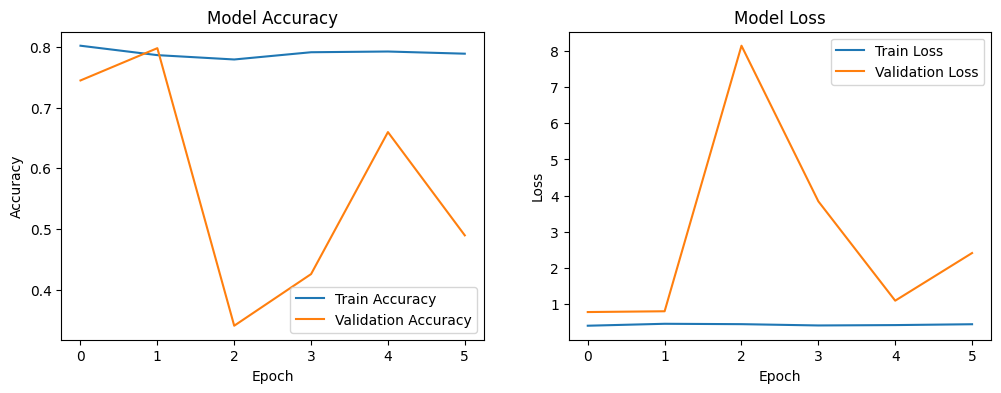

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 141ms/step - accuracy: 0.7535 - loss: 1.4588

Test Accuracy: 0.7394
Test Loss: 1.3267
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 139ms/step

Classification Report:
              precision    recall  f1-score   support

      Benign       0.28      0.83      0.42        18
   Malignant       0.99      0.89      0.94        84
      Normal       0.91      0.51      0.65        63

    accuracy                           0.74       165
   macro avg       0.73      0.74      0.67       165
weighted avg       0.88      0.74      0.77       165



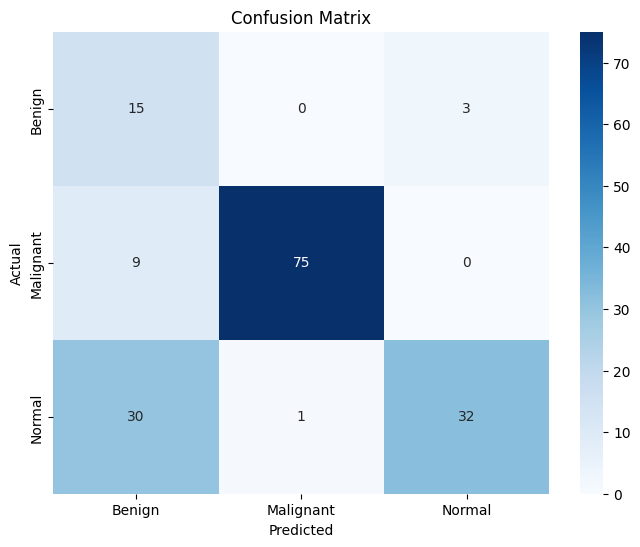

In [ ]:
# Step 8: Evaluate the model
def plot_history(history):
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.show()

plot_history(history)

# Evaluate on test set
test_loss, test_acc = model.evaluate(test_generator)
print(f'\nTest Accuracy: {test_acc:.4f}')
print(f'Test Loss: {test_loss:.4f}')

# Classification report and confusion matrix
test_generator.reset()
y_true = test_generator.classes
y_pred = model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)

class_names = list(train_generator.class_indices.keys())
print("\nClassification Report:")
print(classification_report(y_true, y_pred_classes, target_names=class_names))

plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_true, y_pred_classes)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()